In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn import datasets, linear_model

In [9]:
wine = datasets.load_wine(as_frame = False)
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target

<h1> EDA <h1>

Информация об атрибутах

1. Алкоголь
2. Яблочная кислота
3. Пепел
4. Щелочность золы
5. Магний
6. Общие фенолы
7. Флаваноиды
8. Нефлаваноидные фенолы
9. Проантоцианы
10. Интенсивность цвета
11. Оттенок
12. OD280 / OD315 разбавленных вин
13. Пролин

In [10]:
df

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

In [16]:
np.bincount(df["target"]) #смотрим, сбалансированы ли классы

array([59, 71, 48], dtype=int64)

In [17]:
df.target.value_counts(normalize=True).round(3)

target
1    0.399
0    0.331
2    0.270
Name: proportion, dtype: float64

# ПРЕВАЛИРУЕТ ВТОРОЙ КЛАСС, НО НЕ СИЛЬНО

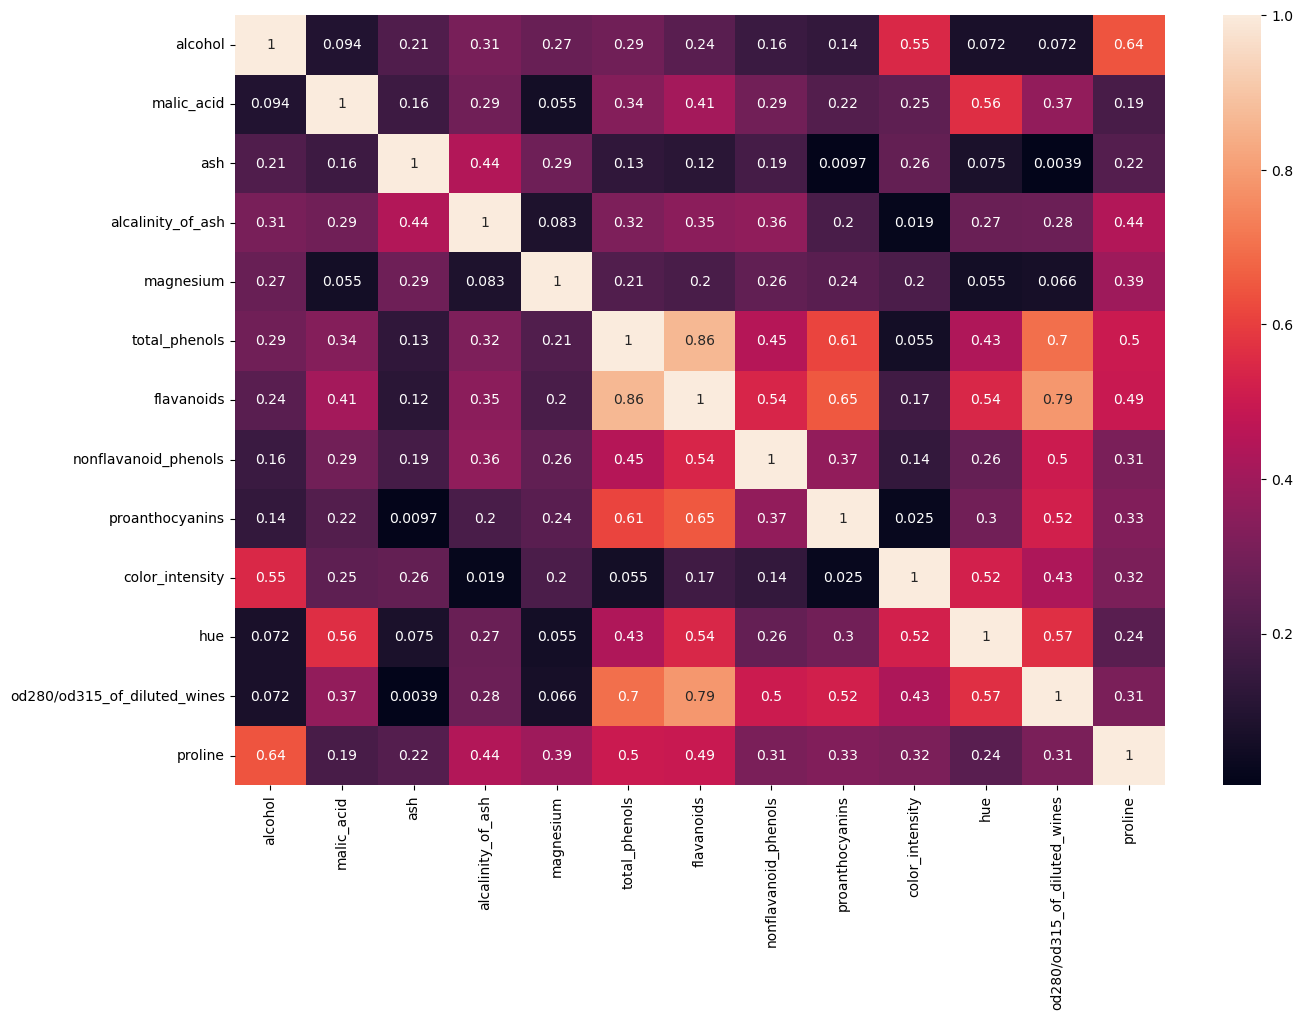

In [18]:
plt.figure(figsize=(15,10))
corr = df.iloc[:,:-1].corr().abs()
ax = sns.heatmap(corr, annot=True)

<h1> Наблюдается высокая куорреляция у полей flavanoids/total_phenols и flavanoids/od280/od315_of_diluted_wines. Это означет, что для анализа понадобится только series flavanoids<h1>

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


<Figure size 2000x2000 with 0 Axes>

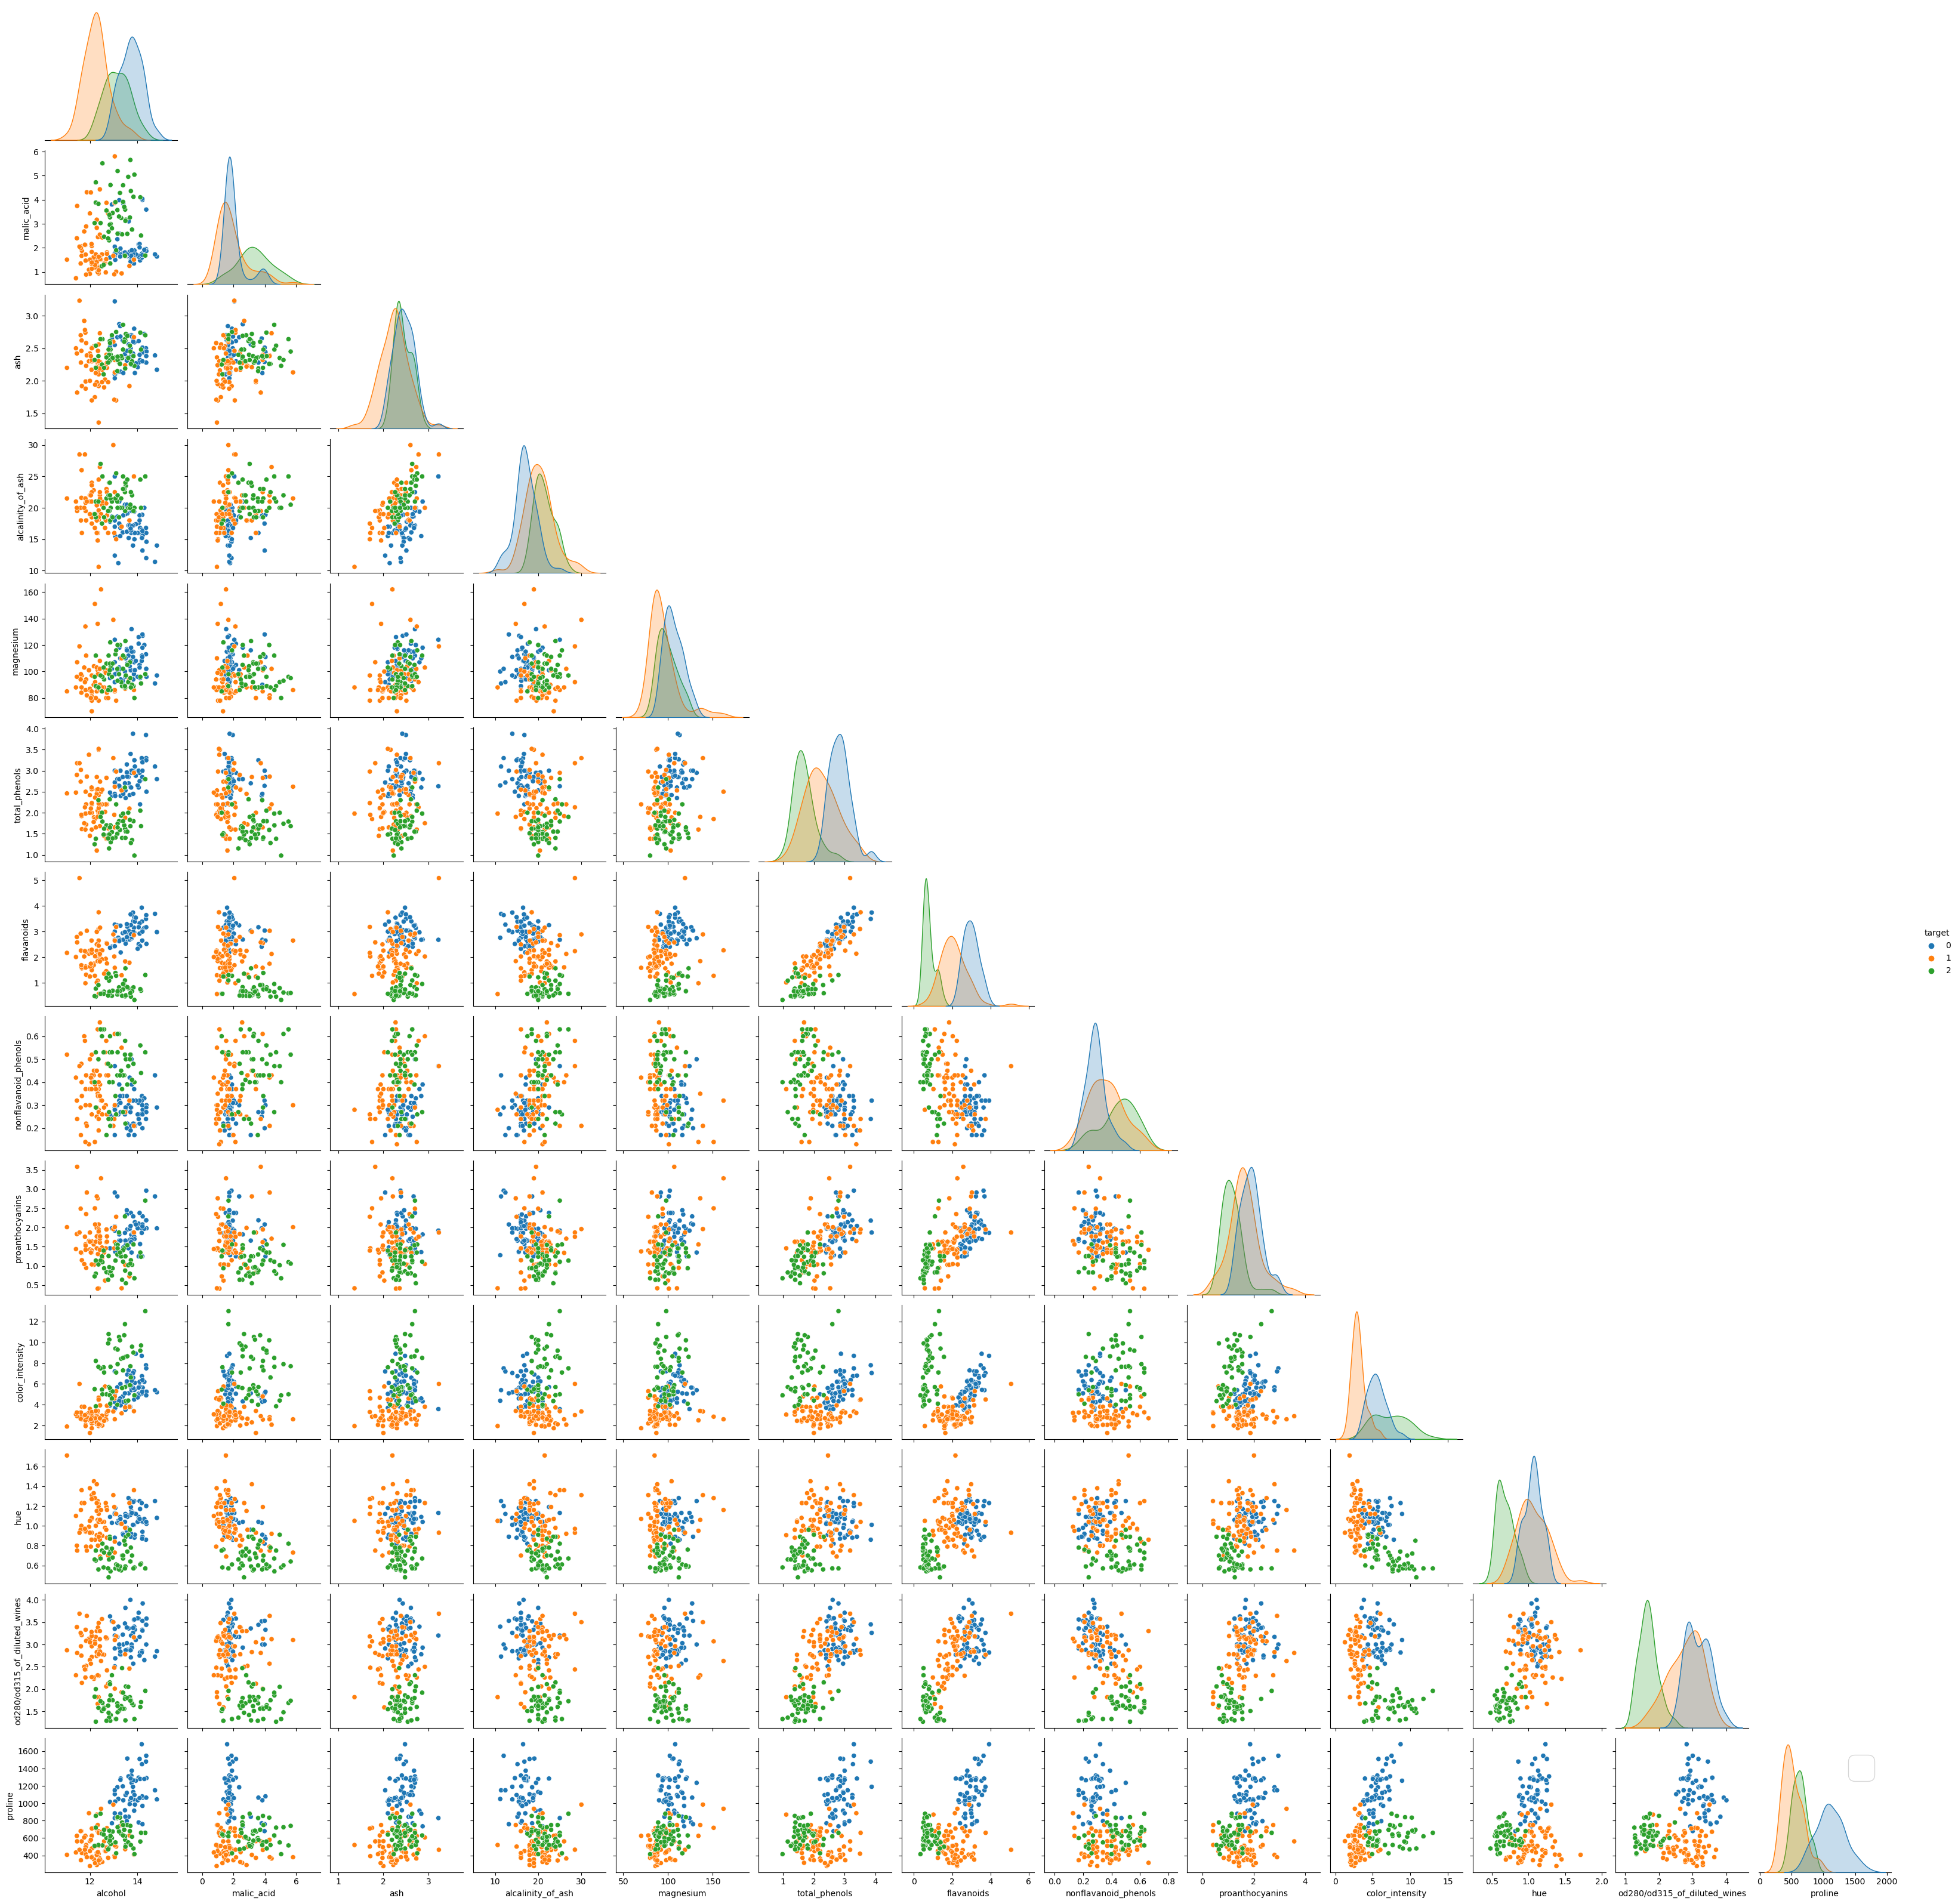

In [22]:
plt.figure(figsize=(20,20))
sns.pairplot(df, 
             hue='target', 
             palette="tab10", 
             corner=True)
plt.legend(fontsize=40)
plt.show()

# Можно заметить, что атрибут flavanoid неплохо разделяет классы.

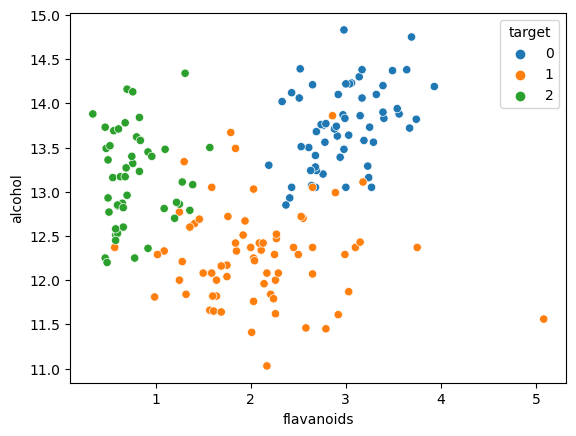

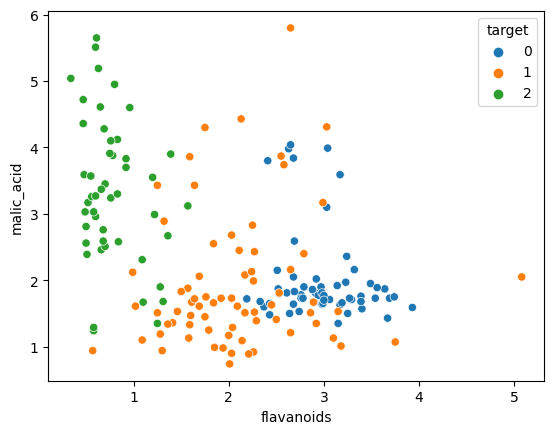

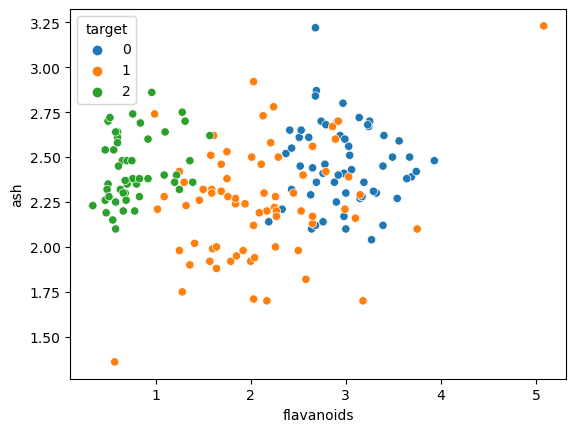

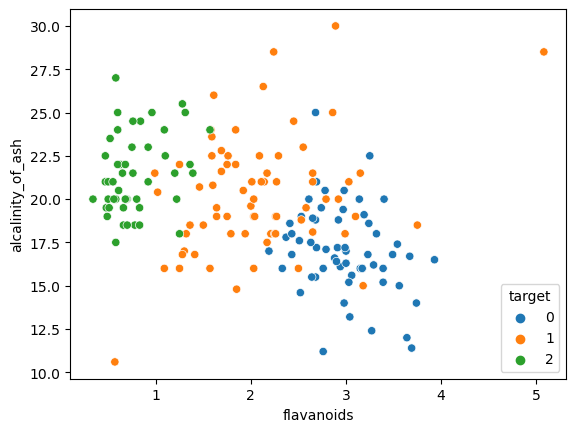

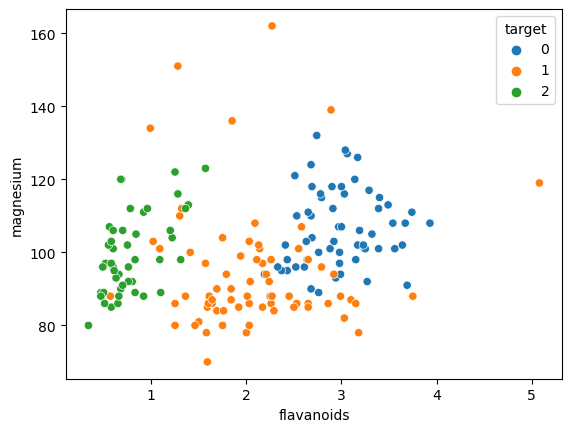

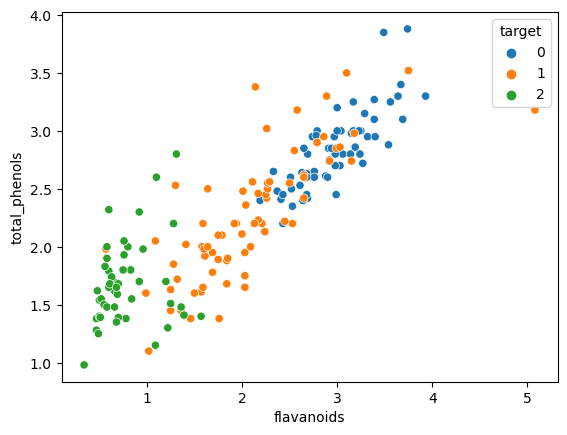

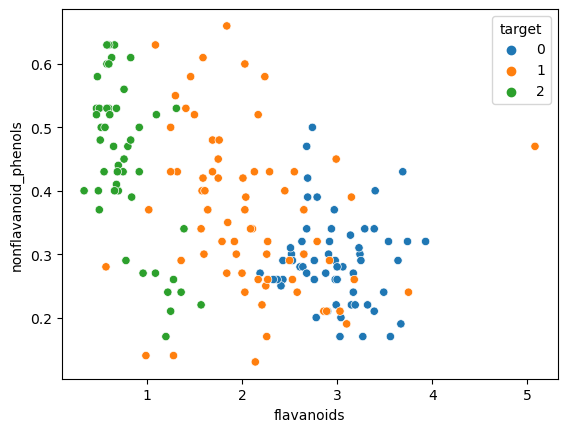

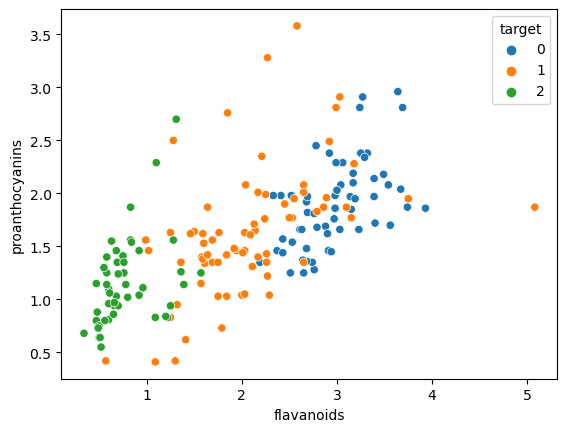

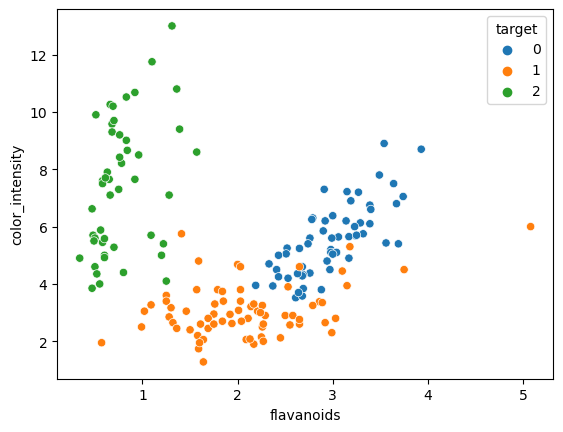

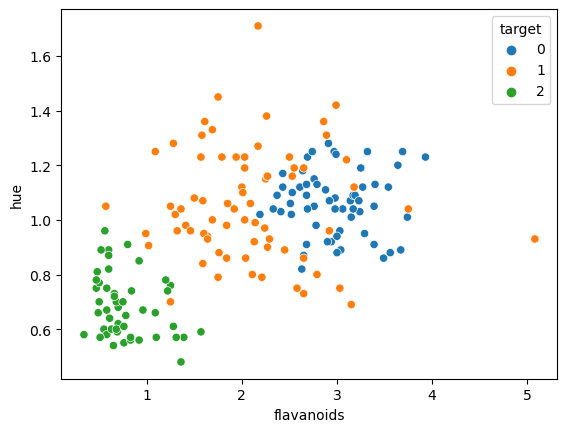

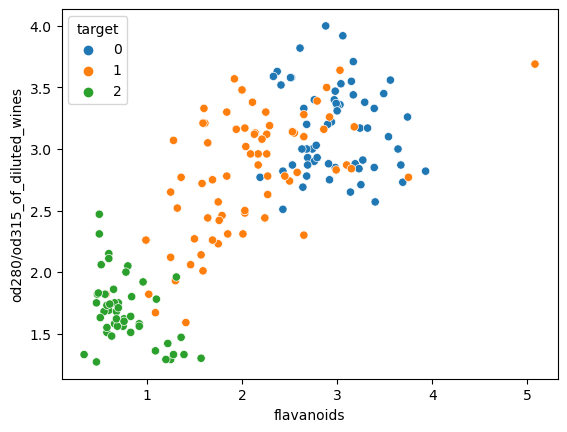

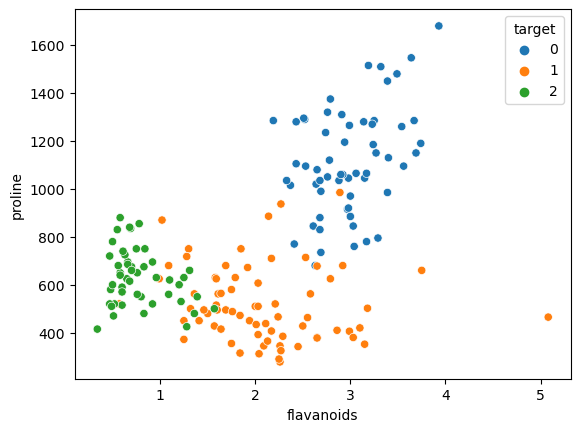

In [41]:
for name, values in df[:-1].items():
    if name != 'flavanoids' and name != 'target':
        sns.scatterplot(data=df, x='flavanoids', y=name, hue='target', palette="tab10")
        plt.show()

In [23]:
df.describe().loc[['min', 'max']].T # просмотр размерностей атрибутов

,min,max
alcohol,11.03,14.83
malic_acid,0.74,5.80
ash,1.36,3.23
alcalinity_of_ash,10.60,30.00
magnesium,70.00,162.00
total_phenols,0.98,3.88
flavanoids,0.34,5.08
nonflavanoid_phenols,0.13,0.66
proanthocyanins,0.41,3.58
color_intensity,1.28,13.00


# Для логистической регресси будут выбраны атрибуты flavanoids и color_intensity.

## Во-первых, атрибут flavanoids хорошо разделяет классы, но имеет высокую корреляцию с атрибутами flavanoids/total_phenols и flavanoids/od280/od315_of_diluted_wines. В сочетании с атрибутом color_intensity атрибут flavanoids разделяет классы вин примерно на три скетора и они имеют маленькую корреляцию.

In [63]:
# Предварительная обработка данных

selected_columns = ['flavanoids', 'color_intensity', 'target']
df_selected = df[selected_columns]
df_selected

,flavanoids,color_intensity,target
0,3.06,5.64,0
1,2.76,4.38,0
2,3.24,5.68,0
3,3.49,7.80,0
4,2.69,4.32,0
...,...,...,...
173,0.61,7.70,2
174,0.75,7.30,2
175,0.69,10.20,2
176,0.68,9.30,2


In [72]:
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score

X = df_selected.drop("target", axis = 1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#scaler = StandardScaler().fit(X_train)
#X_train = scaler.transform(X_train)
#X_test = scaler.transform(X_test)

model = LogisticRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)
print(predictions[:15])

[0 0 2 0 0 0 1 2 1 2 1 2 0 1 0]


In [67]:
# результат с выбранными столбцами
accuracy = accuracy_score(y_test,predictions)*100

confusion_mat = confusion_matrix(y_test,predictions)

print("Accuracy is",accuracy)
print("Confusion Matrix")
print(confusion_mat)

Accuracy is 88.88888888888889
Confusion Matrix
[[13  1  0]
 [ 3 11  0]
 [ 0  0  8]]


In [69]:
# результат со всеми столбцами
accuracy = accuracy_score(y_test,predictions)*100

confusion_mat = confusion_matrix(y_test,predictions)

print("Accuracy is",accuracy)
print("Confusion Matrix")
print(confusion_mat)

Accuracy is 100.0
Confusion Matrix
[[14  0  0]
 [ 0 14  0]
 [ 0  0  8]]


In [73]:
# результат с выбранными столбцами без скалирования
accuracy = accuracy_score(y_test,predictions)*100

confusion_mat = confusion_matrix(y_test,predictions)

print("Accuracy is",accuracy)
print("Confusion Matrix")
print(confusion_mat)

Accuracy is 88.88888888888889
Confusion Matrix
[[13  1  0]
 [ 3 11  0]
 [ 0  0  8]]
